# RFM and RG-VFM on the Pacman dataset

This notebook compares trained RFM and RG-VFM models on the periodic Pacman dataset in $T^2=[0,1)^2$. It restores both checkpoints, evaluates their held-out training objectives, generates samples, visualizes the learned transport, inspects vector fields, and reports distribution-level metrics.

## 1. Setup

The defaults are suitable for a full comparison. For a quick smoke test, reduce `PACMAN_N_SAMPLES` and `PACMAN_N_STEPS`. Checkpoints can be supplied explicitly with `PACMAN_RFM_CHECKPOINT` and `PACMAN_RGVFM_CHECKPOINT`.

In [1]:
import os
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from torch.utils.data import DataLoader

# Make imports work when Jupyter starts in the repository or a subdirectory.
PROJECT_ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / 'src').is_dir() and (path / 'data/pacman.npy').is_file()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.dataLib.synthetic import Pacman_Dataset
from src.device import get_default_device
from src.litTrain.trainLitRFMMLP import (
    build_model as build_rfm_model,
    build_rfm,
)
from src.litTrain.trainLitRGVFMMLP import (
    build_model as build_rgvfm_model,
    build_rg_vfm,
)
from src.manifolds import FlatTorus01

SEED = int(os.getenv('PACMAN_SEED', '2026'))
N_SAMPLES = int(os.getenv('PACMAN_N_SAMPLES', '4096'))
N_STEPS = int(os.getenv('PACMAN_N_STEPS', '100'))
TEST_SIZE = int(os.getenv('PACMAN_TEST_SIZE', '4096'))
TEST_BATCH_SIZE = 512
HISTOGRAM_BINS = int(os.getenv('PACMAN_HISTOGRAM_BINS', '40'))
DEVICE = get_default_device()
PACMAN_PATH = PROJECT_ROOT / 'data/pacman.npy'
METHODS = ('rfm', 'rgvfm')
LABELS = {'rfm': 'RFM', 'rgvfm': 'RG-VFM'}
COLORS = {'rfm': 'tab:orange', 'rgvfm': 'tab:purple'}

if N_SAMPLES < 1 or N_STEPS < 1 or TEST_SIZE < 1:
    raise ValueError('sample count, ODE steps, and test size must be positive')

torch.manual_seed(SEED)
np.random.seed(SEED)
print(f'project={PROJECT_ROOT}')
print(f'device={DEVICE}, samples/model={N_SAMPLES}, ODE steps={N_STEPS}')

project=/Users/jizho/project_codes/diffusion-playground
device=mps, samples/model=4096, ODE steps=100


## 2. Restore both trained models

For each method, the notebook searches only Pacman experiment directories, so a checkerboard checkpoint cannot be selected accidentally. A distribution-selected checkpoint is preferred when present; otherwise the lowest validation-loss checkpoint is used. The model and flow are constructed with the same builders used by training, then the saved `model.*` tensors are loaded directly from the Lightning checkpoint's `state_dict`.

In [2]:
def checkpoint_metric(path: Path) -> float:
    match = re.search(r'-(\d+(?:\.\d+)?)\.ckpt$', path.name)
    return float(match.group(1)) if match else float('inf')


def find_pacman_checkpoint(project_root: Path, method: str) -> Path:
    experiment = (
        'RFMMLP_pacman_fractional'
        if method == 'rfm'
        else 'RGVFMMLP_pacman_fractional'
    )
    checkpoint_root = project_root / 'checkpoints'
    experiment_dirs = [
        path for path in checkpoint_root.rglob(experiment) if path.is_dir()
    ] if checkpoint_root.is_dir() else []
    candidates = [
        checkpoint
        for directory in experiment_dirs
        for checkpoint in directory.glob('*.ckpt')
    ]
    if not candidates:
        env_name = f'PACMAN_{method.upper()}_CHECKPOINT'
        raise FileNotFoundError(
            f'No {LABELS[method]} Pacman checkpoint found under checkpoints/. '
            f'Train the model first or set {env_name} to its .ckpt file.'
        )

    distribution = [path for path in candidates if 'distribution_' in path.name]
    regular = [path for path in candidates if path.name != 'last.ckpt']
    preferred = distribution or regular
    if preferred:
        return min(preferred, key=lambda path: (checkpoint_metric(path), str(path)))
    return max(candidates, key=lambda path: path.stat().st_mtime)


def resolve_checkpoint(method: str) -> Path:
    override = os.getenv(f'PACMAN_{method.upper()}_CHECKPOINT')
    if not override:
        return find_pacman_checkpoint(PROJECT_ROOT, method)
    path = Path(override).expanduser()
    if not path.is_absolute():
        path = PROJECT_ROOT / path
    if not path.is_file():
        raise FileNotFoundError(f'checkpoint does not exist: {path}')
    return path


def display_path(path: Path) -> str:
    try:
        return str(path.relative_to(PROJECT_ROOT))
    except ValueError:
        return str(path)


manifold = FlatTorus01(dim=2)
checkpoint_paths = {method: resolve_checkpoint(method) for method in METHODS}
checkpoint_paths['rgvfm'] = (PROJECT_ROOT / 'checkpoints/20260903_172328/20260903_184159/RGVFMMLP_pacman_fractional/rgvfm_mlp_0218-0.007335.ckpt')
model_builders = {
    'rfm': build_rfm_model,
    'rgvfm': build_rgvfm_model,
}
flow_builders = {
    'rfm': build_rfm,
    'rgvfm': build_rg_vfm,
}
checkpoints = {}
models = {}
flows = {method: flow_builders[method](manifold) for method in METHODS}

for method in METHODS:
    checkpoint = torch.load(
        checkpoint_paths[method], map_location='cpu', weights_only=True
    )
    model_state = {
        key.removeprefix('model.'): value
        for key, value in checkpoint['state_dict'].items()
        if key.startswith('model.')
    }
    model = model_builders[method](manifold)
    model.load_state_dict(model_state, strict=True)
    model.to(DEVICE).eval()
    checkpoints[method] = checkpoint
    models[method] = model

checkpoint_summary = pd.DataFrame([
    {
        'method': LABELS[method],
        'epoch': checkpoints[method].get('epoch', 'unknown'),
        'checkpoint': display_path(checkpoint_paths[method]),
    }
    for method in METHODS
]).set_index('method')
display(checkpoint_summary)

,epoch,checkpoint
method,,
RFM,865,checkpoints/20260901_173346/RFMMLP_pacman_frac...
RG-VFM,218,checkpoints/20260903_172328/20260903_184159/RG...


## 3. Pacman reference distribution

`Pacman_Dataset` applies the same global normalization used during training. Values on the upper boundary are wrapped to the canonical torus interval $[0,1)$ before visualization and metric calculation.

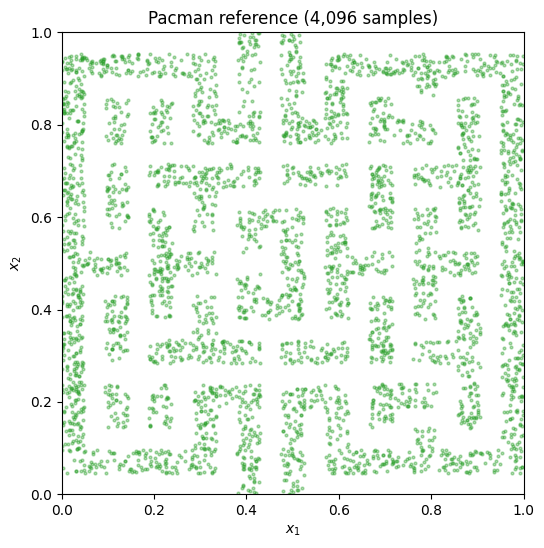

In [3]:
pacman_dataset = Pacman_Dataset(PACMAN_PATH)
reference_pool = manifold.wrap(pacman_dataset.data.float()).cpu()

def sample_reference(n_samples: int, seed: int) -> torch.Tensor:
    generator = torch.Generator().manual_seed(seed)
    indices = torch.randint(
        len(reference_pool), (n_samples,), generator=generator
    )
    return reference_pool[indices]


reference = sample_reference(N_SAMPLES, SEED + 100)
reference_noise_floor = sample_reference(N_SAMPLES, SEED + 200)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(
    reference[:, 0], reference[:, 1], s=4, alpha=0.38,
    color='tab:green', rasterized=True,
)
ax.set(
    title=f'Pacman reference ({N_SAMPLES:,} samples)',
    xlabel='$x_1$', ylabel='$x_2$', xlim=(0, 1), ylim=(0, 1),
)
ax.set_aspect('equal')
plt.show()

## 4. Held-out training objectives

RFM predicts tangent velocity and is compared with a zero-velocity baseline. RG-VFM predicts the terminal point and is compared with an identity endpoint $\hat{x}_T=x_t$. The objective scales differ, so compare each model with its own baseline rather than comparing the two raw losses directly.

In [ ]:
test_dataset = Pacman_Dataset(
    PACMAN_PATH, size=TEST_SIZE, seed=50_000
)
test_loader = DataLoader(
    test_dataset, batch_size=TEST_BATCH_SIZE, shuffle=False
)
def evaluate_objective(method: str) -> dict[str, float | str]:
    model = models[method]
    flow = flows[method]
    loss_sum = 0.0
    baseline_sum = 0.0
    count = 0
    torch.manual_seed(SEED + 300)

    with torch.inference_mode():
        for x_data in test_loader:
            x_data = x_data.to(DEVICE, dtype=next(model.parameters()).dtype)
            t, x_t, target = flow.sample_training_pair(x_data)
            prediction = model(t, x_t)
            baseline_prediction = (
                torch.zeros_like(target) if method == 'rfm' else x_t
            )
            loss = flow.loss(prediction, target, x_t=x_t, t=t)
            baseline = flow.loss(
                baseline_prediction, target, x_t=x_t, t=t
            )
            batch_size = x_data.shape[0]
            loss_sum += loss.item() * batch_size
            baseline_sum += baseline.item() * batch_size
            count += batch_size

    loss_mean = loss_sum / count
    baseline_mean = baseline_sum / count
    return {
        'method': LABELS[method],
        'objective': 'velocity MSE' if method == 'rfm' else 'geodesic endpoint loss',
        'heldout_loss': loss_mean,
        'baseline_loss': baseline_mean,
        'relative_gain': 1.0 - loss_mean / max(baseline_mean, 1e-12),
    }


objective_rows = [evaluate_objective(method) for method in METHODS]
objective_metrics = pd.DataFrame(objective_rows).set_index('method')
display(objective_metrics.style.format({
    'heldout_loss': '{:.6f}',
    'baseline_loss': '{:.6f}',
    'relative_gain': '{:.2%}',
}))

## 5. Generate samples from both learned flows

Each method uses the prior it was trained with and transports it from $t=0$ to $t=1$. The complete ODE trajectory is retained for the snapshot plots below.

In [ ]:
priors = {}
trajectories = {}
time_grids = {}
generated = {}

for offset, method in enumerate(METHODS):
    model = models[method]
    flow = flows[method]
    torch.manual_seed(SEED + 400 + offset)
    parameter = next(model.parameters())
    x_0 = flow.sample_prior(
        (N_SAMPLES, 2), device=DEVICE, dtype=parameter.dtype
    )
    with torch.inference_mode():
        time_grid, trajectory = flow.sample(
            model, x_0, n_steps=N_STEPS, return_trajectory=True
        )
    priors[method] = manifold.wrap(x_0).cpu()
    trajectories[method] = trajectory.cpu()
    time_grids[method] = time_grid.cpu()
    generated[method] = manifold.wrap(trajectory[-1]).cpu()
    assert generated[method].shape == (N_SAMPLES, 2)
    assert torch.all((generated[method] >= 0) & (generated[method] < 1))
    print(f'{LABELS[method]}: generated {N_SAMPLES:,} valid torus samples')

RFM: generated 4,096 valid torus samples
RG-VFM: generated 4,096 valid torus samples


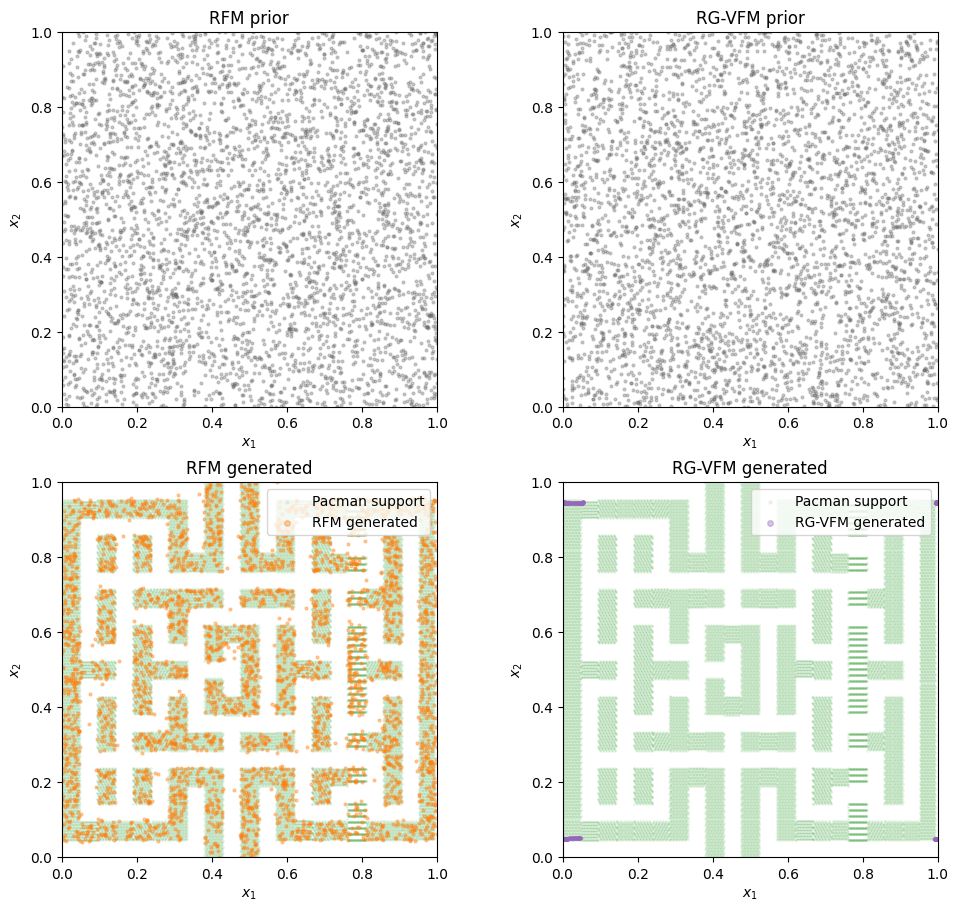

In [ ]:
def format_torus_axis(ax, title: str) -> None:
    ax.set(
        title=title, xlabel='$x_1$', ylabel='$x_2$',
        xlim=(0, 1), ylim=(0, 1),
    )
    ax.set_aspect('equal')


def add_reference_background(ax, max_points: int = 30_000) -> None:
    stride = max(1, len(reference_pool) // max_points)
    background = reference_pool[::stride][:max_points]
    ax.scatter(
        background[:, 0], background[:, 1], s=1.2, alpha=0.08,
        color='tab:green', rasterized=True, label='Pacman support',
    )


fig, axes = plt.subplots(2, 2, figsize=(10, 9), constrained_layout=True)
for column, method in enumerate(METHODS):
    axes[0, column].scatter(
        priors[method][:, 0], priors[method][:, 1],
        s=4, alpha=0.32, color='0.4', rasterized=True,
    )
    format_torus_axis(axes[0, column], f'{LABELS[method]} prior')

    add_reference_background(axes[1, column])
    axes[1, column].scatter(
        generated[method][:, 0], generated[method][:, 1],
        s=4, alpha=0.38, color=COLORS[method], rasterized=True,
        label=f'{LABELS[method]} generated',
    )
    format_torus_axis(axes[1, column], f'{LABELS[method]} generated')
    axes[1, column].legend(loc='upper right', markerscale=2)
plt.show()

## 6. Learned transport trajectories

The rows show how each model moves its prior toward the Pacman distribution. Look for missing corridors, density collapse, or unnatural accumulation across the periodic boundary.

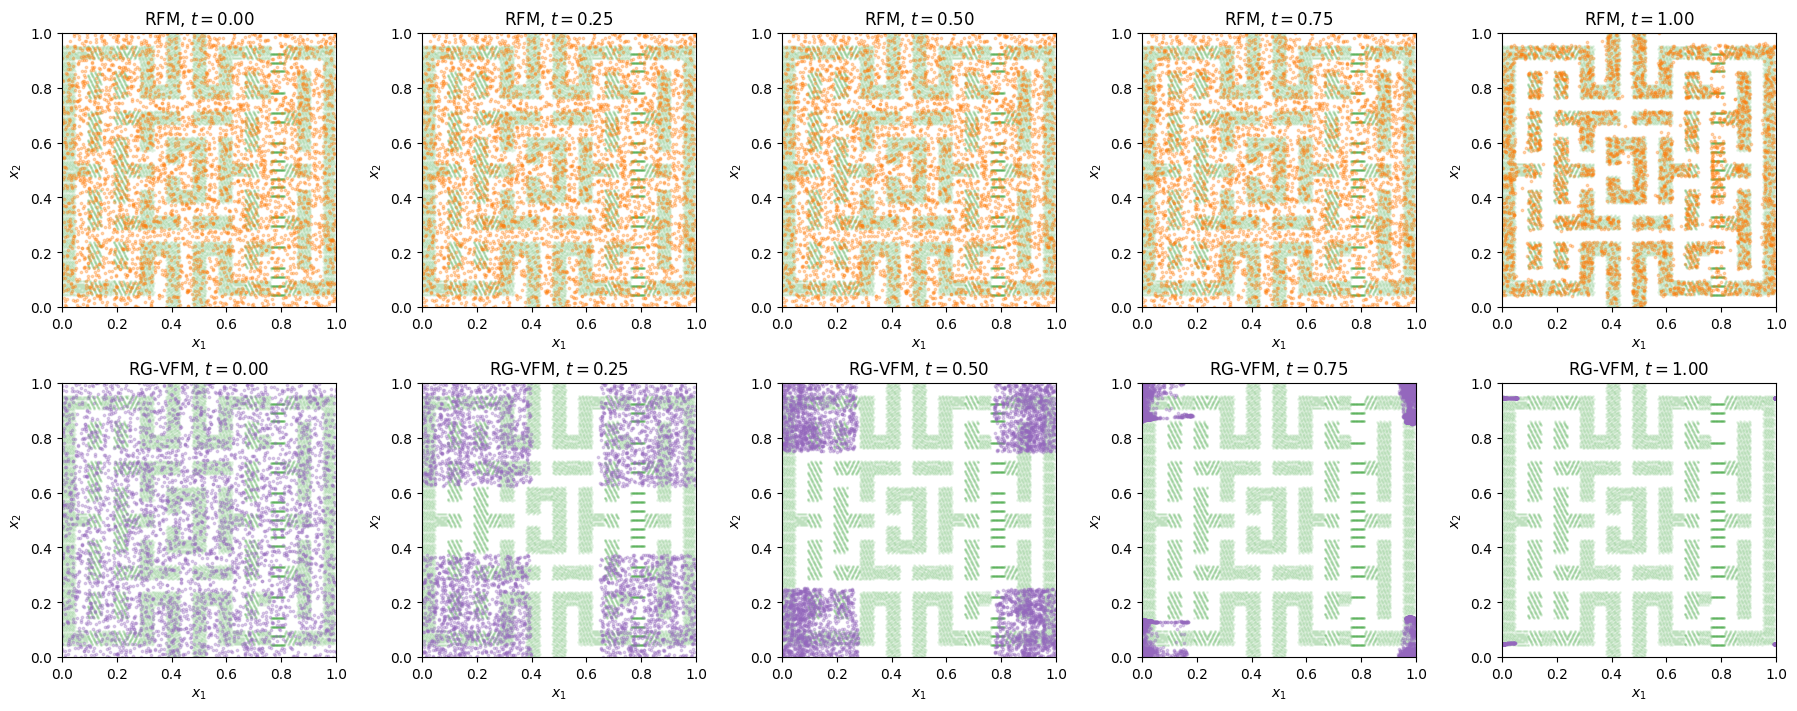

In [ ]:
snapshot_fractions = [0.0, 0.25, 0.5, 0.75, 1.0]
snapshot_indices = [round(fraction * N_STEPS) for fraction in snapshot_fractions]
fig, axes = plt.subplots(
    2, len(snapshot_indices), figsize=(18, 7), constrained_layout=True
)

for row, method in enumerate(METHODS):
    for column, index in enumerate(snapshot_indices):
        ax = axes[row, column]
        add_reference_background(ax, max_points=15_000)
        points = manifold.wrap(trajectories[method][index])
        ax.scatter(
            points[:, 0], points[:, 1], s=3, alpha=0.3,
            color=COLORS[method], rasterized=True,
        )
        time = time_grids[method][index].item()
        format_torus_axis(ax, f'{LABELS[method]}, $t={time:.2f}$')
plt.show()

## 7. Learned vector fields

Arrow direction shows the learned transport direction; color encodes speed. RG-VFM endpoint predictions are converted to tangent velocities by the flow object before plotting.

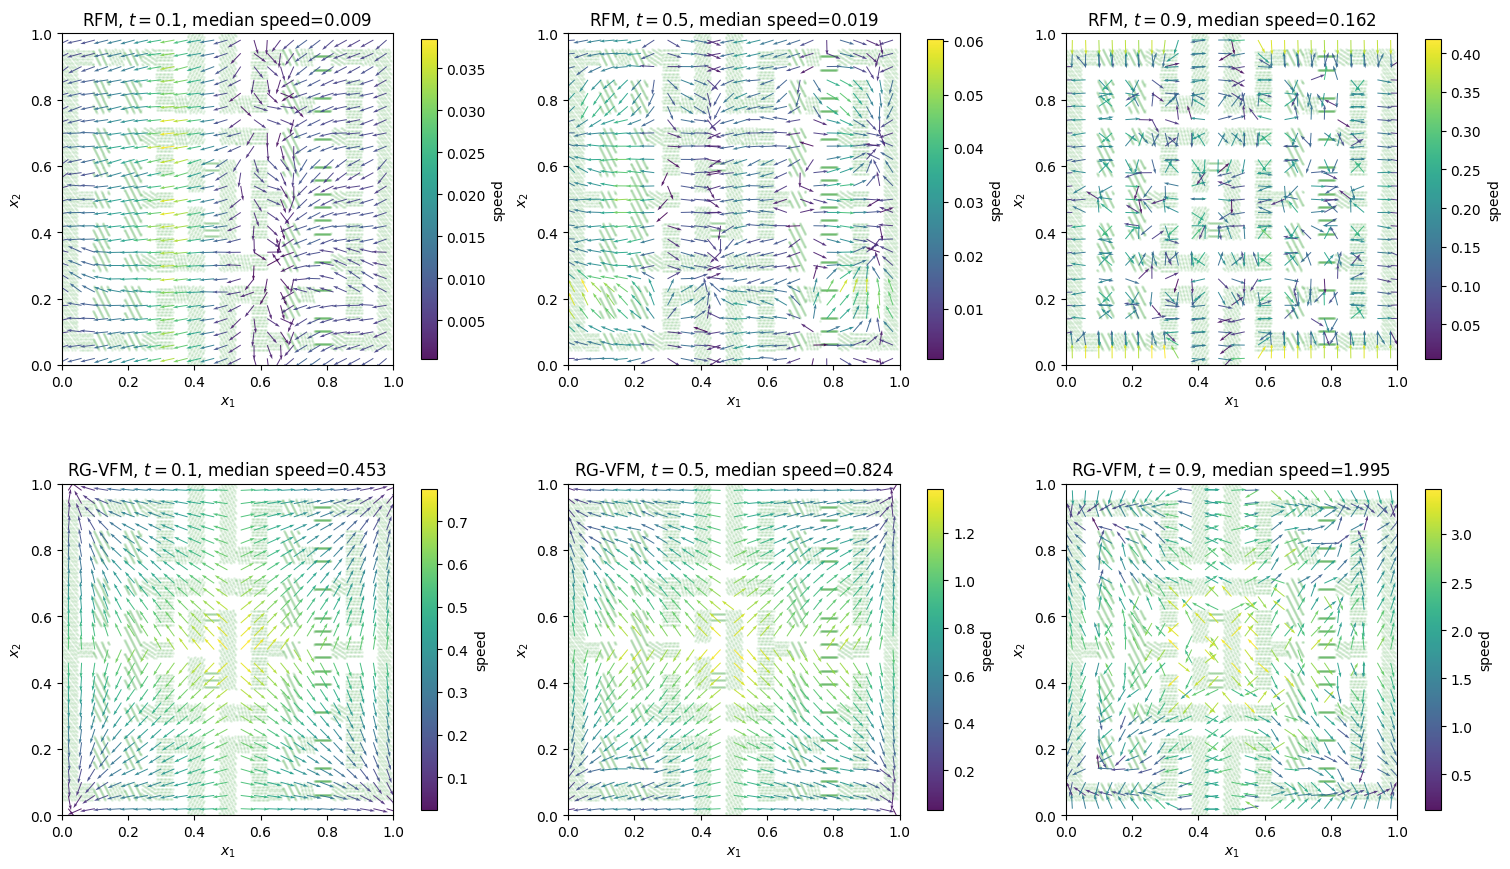

In [ ]:
grid_axis = torch.linspace(0.02, 0.98, 25, device=DEVICE)
grid_x, grid_y = torch.meshgrid(grid_axis, grid_axis, indexing='xy')
grid = torch.stack([grid_x.reshape(-1), grid_y.reshape(-1)], dim=-1)
field_times = [0.1, 0.5, 0.9]

fig, axes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)
for row, method in enumerate(METHODS):
    model = models[method]
    flow = flows[method]
    model_dtype = next(model.parameters()).dtype
    model_grid = grid.to(dtype=model_dtype)
    for column, time in enumerate(field_times):
        ax = axes[row, column]
        with torch.inference_mode():
            velocity = flow.vector_field(model, time, model_grid).cpu()
        speed = torch.linalg.vector_norm(velocity, dim=-1)
        direction = velocity / speed.clamp_min(1e-8).unsqueeze(-1)
        add_reference_background(ax, max_points=12_000)
        quiver = ax.quiver(
            model_grid[:, 0].cpu(), model_grid[:, 1].cpu(),
            direction[:, 0], direction[:, 1], speed,
            cmap='viridis', angles='xy', scale_units='xy', scale=22,
            width=0.003, alpha=0.9,
        )
        format_torus_axis(
            ax, f'{LABELS[method]}, $t={time:.1f}$, median speed={speed.median():.3f}'
        )
        fig.colorbar(quiver, ax=ax, shrink=0.75, label='speed')
plt.show()

## 8. Distribution-level metrics

Histogram TV and Jensen-Shannon divergence measure density mismatch (lower is better). `support_precision` is the fraction of samples landing in a histogram cell occupied by the full Pacman dataset, while `target_mass_covered` is the fraction of reference probability mass covered by at least one generated sample (higher is better). The independent reference sample estimates the finite-sample noise floor.

In [ ]:
def normalized_histogram(points: torch.Tensor, bins: int) -> np.ndarray:
    counts = np.histogram2d(
        points[:, 0].numpy(), points[:, 1].numpy(),
        bins=bins, range=[[0, 1], [0, 1]],
    )[0]
    return counts / max(counts.sum(), 1.0)


target_histogram = normalized_histogram(reference_pool, HISTOGRAM_BINS)

def distribution_metrics(points: torch.Tensor) -> dict[str, float]:
    points = manifold.wrap(points).cpu()
    observed = normalized_histogram(points, HISTOGRAM_BINS)
    target = target_histogram
    midpoint = 0.5 * (observed + target)
    eps = 1e-12

    histogram_tv = 0.5 * np.abs(observed - target).sum()
    jsd = 0.5 * np.sum(
        observed * np.log((observed + eps) / (midpoint + eps))
    )
    jsd += 0.5 * np.sum(
        target * np.log((target + eps) / (midpoint + eps))
    )

    array = points.numpy()
    bin_x = np.floor(array[:, 0] * HISTOGRAM_BINS).astype(int)
    bin_y = np.floor(array[:, 1] * HISTOGRAM_BINS).astype(int)
    bin_x = np.clip(bin_x, 0, HISTOGRAM_BINS - 1)
    bin_y = np.clip(bin_y, 0, HISTOGRAM_BINS - 1)
    target_support = target > 0
    support_precision = target_support[bin_x, bin_y].mean()
    target_mass_covered = target[observed > 0].sum()

    return {
        'histogram_TV': float(histogram_tv),
        'Jensen_Shannon': float(jsd),
        'support_precision': float(support_precision),
        'target_mass_covered': float(target_mass_covered),
    }


metric_samples = {
    'RFM prior': priors['rfm'],
    'RG-VFM prior': priors['rgvfm'],
    'RFM generated': generated['rfm'],
    'RG-VFM generated': generated['rgvfm'],
    'reference (noise floor)': reference_noise_floor,
}
distribution_table = pd.DataFrame([
    {'sample': name, **distribution_metrics(points)}
    for name, points in metric_samples.items()
]).set_index('sample')
display(distribution_table.style.format('{:.4f}'))

,histogram_TV,Jensen_Shannon,support_precision,target_mass_covered
sample,,,,
RFM prior,0.4479,0.1943,0.6975,0.9343
RG-VFM prior,0.4426,0.1921,0.7063,0.9172
RFM generated,0.2121,0.0460,0.9897,0.9633
RG-VFM generated,0.9916,0.6763,1.0000,0.0084
reference (noise floor),0.2016,0.0395,1.0000,0.9684


### Interpretation

A successful model should beat its own held-out baseline, visibly reproduce Pacman's corridors and open regions, reduce histogram TV/Jensen-Shannon divergence toward the reference noise floor, and improve both support precision and target-mass coverage over its prior. Use the trajectory and vector-field plots to distinguish mode collapse from integration or periodic-boundary artifacts.